In [16]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [17]:
import pandas as pd

data_df = pd.concat([X, y], axis=1)

print(data_df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  


In [18]:
X

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [19]:
X.shape

(45211, 16)

In [20]:
y.shape

(45211, 1)

In [21]:
import joblib
from sklearn.preprocessing import LabelEncoder
lab_enc = LabelEncoder()
y['y'] = lab_enc.fit_transform(y['y'])

In [22]:
joblib.dump(y,"y.pkl")

['y.pkl']

In [23]:
import numpy  as np
y_arr =np.array(y).reshape(-1)

In [24]:
y_arr.shape

(45211,)

In [25]:
object_col = X.select_dtypes(include='object')
object_col

C:\Users\HP5CD\AppData\Local\Temp\ipykernel_20872\3955416564.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_col = X.select_dtypes(include='object')


,job,marital,education,default,housing,loan,contact,month,poutcome
0,management,married,tertiary,no,yes,no,NaN,may,NaN
1,technician,single,secondary,no,yes,no,NaN,may,NaN
2,entrepreneur,married,secondary,no,yes,yes,NaN,may,NaN
3,blue-collar,married,NaN,no,yes,no,NaN,may,NaN
4,NaN,single,NaN,no,no,no,NaN,may,NaN
...,...,...,...,...,...,...,...,...,...
45206,technician,married,tertiary,no,no,no,cellular,nov,NaN
45207,retired,divorced,primary,no,no,no,cellular,nov,NaN
45208,retired,married,secondary,no,no,no,cellular,nov,success
45209,blue-collar,married,secondary,no,no,no,telephone,nov,NaN


In [26]:
import seaborn as sns
for i in object_col:
    print(X[i].value_counts())

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
no     37967
yes     7244
Name: count, dtype: int64
contact
cellular     29285
telephone     2906
Name: count, dtype: int64
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
poutcome
failure    4901
other      1840
success    1511
Name: count, dtype: int64


In [27]:
X.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

In [28]:
X.drop(columns=['contact', 'poutcome'], inplace=True)

In [29]:
X.isnull().sum()

age               0
job             288
marital           0
education      1857
default           0
balance           0
housing           0
loan              0
day_of_week       0
month             0
duration          0
campaign          0
pdays             0
previous          0
dtype: int64

In [30]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   day_of_week  45211 non-null  int64
 9   month        45211 non-null  str  
 10  duration     45211 non-null  int64
 11  campaign     45211 non-null  int64
 12  pdays        45211 non-null  int64
 13  previous     45211 non-null  int64
dtypes: int64(7), str(7)
memory usage: 4.8 MB


In [31]:
X['job'].fillna(X['job'].mode()[0],inplace = True)
X['education'].fillna(X['education'].mode()[0],inplace = True)

C:\Users\HP5CD\AppData\Local\Temp\ipykernel_20872\1103318050.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X['job'].fillna(X['job'].mode()[0],inplace = True)
C:\Users\HP5CD\AppData\Local\Temp\ipykernel_20872\1103318050.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignme

0         tertiary
1        secondary
2        secondary
3        secondary
4        secondary
           ...    
45206     tertiary
45207      primary
45208    secondary
45209    secondary
45210    secondary
Name: education, Length: 45211, dtype: str

In [32]:
X.isnull().sum()

age               0
job             288
marital           0
education      1857
default           0
balance           0
housing           0
loan              0
day_of_week       0
month             0
duration          0
campaign          0
pdays             0
previous          0
dtype: int64

In [33]:
object_col

,job,marital,education,default,housing,loan,contact,month,poutcome
0,management,married,tertiary,no,yes,no,NaN,may,NaN
1,technician,single,secondary,no,yes,no,NaN,may,NaN
2,entrepreneur,married,secondary,no,yes,yes,NaN,may,NaN
3,blue-collar,married,NaN,no,yes,no,NaN,may,NaN
4,NaN,single,NaN,no,no,no,NaN,may,NaN
...,...,...,...,...,...,...,...,...,...
45206,technician,married,tertiary,no,no,no,cellular,nov,NaN
45207,retired,divorced,primary,no,no,no,cellular,nov,NaN
45208,retired,married,secondary,no,no,no,cellular,nov,success
45209,blue-collar,married,secondary,no,no,no,telephone,nov,NaN


In [34]:
object_col = X.select_dtypes(include='object')

C:\Users\HP5CD\AppData\Local\Temp\ipykernel_20872\1079155050.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_col = X.select_dtypes(include='object')


In [35]:
import joblib
from sklearn.preprocessing import LabelEncoder
encoder = {}
for i in object_col:
    lab_enc = LabelEncoder()
    X[i] = lab_enc.fit_transform(X[i])
    encoder[i] = lab_enc

In [36]:
print(encoder)

{'job': LabelEncoder(), 'marital': LabelEncoder(), 'education': LabelEncoder(), 'default': LabelEncoder(), 'housing': LabelEncoder(), 'loan': LabelEncoder(), 'month': LabelEncoder()}


In [37]:
joblib.dump(encoder,"encoder.pkl")

['encoder.pkl']

In [38]:
X.head()

,age,job,marital,education,default,balance,housing,loan,day_of_week,month,duration,campaign,pdays,previous
0,58,4,1,2,0,2143,1,0,5,8,261,1,-1,0
1,44,9,2,1,0,29,1,0,5,8,151,1,-1,0
2,33,2,1,1,0,2,1,1,5,8,76,1,-1,0
3,47,1,1,3,0,1506,1,0,5,8,92,1,-1,0
4,33,11,2,3,0,1,0,0,5,8,198,1,-1,0


In [39]:
from sklearn.preprocessing import MinMaxScaler
min_max_scale = MinMaxScaler()
normalize_col = ['age','balance','duration']

X[normalize_col] = min_max_scale.fit_transform(X[normalize_col])


In [40]:
X

,age,job,marital,education,default,balance,housing,loan,day_of_week,month,duration,campaign,pdays,previous
0,0.519481,4,1,2,0,0.092259,1,0,5,8,0.053070,1,-1,0
1,0.337662,9,2,1,0,0.073067,1,0,5,8,0.030704,1,-1,0
2,0.194805,2,1,1,0,0.072822,1,1,5,8,0.015453,1,-1,0
3,0.376623,1,1,3,0,0.086476,1,0,5,8,0.018707,1,-1,0
4,0.194805,11,2,3,0,0.072812,0,0,5,8,0.040260,1,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.428571,9,1,2,0,0.080293,0,0,17,9,0.198658,3,-1,0
45207,0.688312,5,0,0,0,0.088501,0,0,17,9,0.092721,2,-1,0
45208,0.701299,5,1,1,0,0.124689,0,0,17,9,0.229158,5,184,3
45209,0.506494,1,1,1,0,0.078868,0,0,17,9,0.103294,4,-1,0


In [41]:
y_arr

array([0, 0, 0, ..., 1, 0, 0], shape=(45211,))

In [42]:
# y_arr['y'] = lab_enc.fit_transform(y['y_arr'])

In [43]:
# joblib.dump(y,"y.pkl")

In [44]:
y_arr

array([0, 0, 0, ..., 1, 0, 0], shape=(45211,))

In [45]:
y = y_arr

In [46]:
from sklearn.model_selection import train_test_split, KFold,cross_val_score
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

In [47]:
from sklearn.tree import DecisionTreeClassifier
dtc_model = DecisionTreeClassifier()

In [48]:
kfold = KFold(n_splits=5)
validation_score = cross_val_score(dtc_model,
                                   X_train,
                                   y_train,
                                   cv = kfold)

In [49]:
print(validation_score)
print(validation_score.mean()*100)

[0.87254631 0.86881393 0.86950511 0.87045486 0.86824278]
86.99125987734541


In [50]:
dtc_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [51]:
y_pred = dtc_model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [52]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(accuracy_score(y_test,y_pred))

0.8705075749198274


In [53]:
print(confusion_matrix(y_test,y_pred))

[[7387  622]
 [ 549  485]]


In [54]:
joblib.dump(dtc_model,"dtc_model.pkl")

['dtc_model.pkl']

# Artificial N N


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [57]:
X_train.shape[1]

14

# Model Architecture 

In [59]:
model = Sequential()

#hidden layer1
model.add(Dense(64,activation = 'relu',input_dim = X_train.shape[1]))

#hidden layer2
model.add(Dense(32,activation = 'relu'))

#output layer
model.add(Dense(1,activation = 'sigmoid'))

# Model Optimization


In [60]:
model.compile(optimizer = 'adam',loss = 'binary_crossentropy',metrics = ['accuracy'])

# Model Training


In [67]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs = 50)

Epoch 1/50
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8982 - loss: 0.2338 - val_accuracy: 0.8901 - val_loss: 0.2489
Epoch 2/50
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8995 - loss: 0.2334 - val_accuracy: 0.8931 - val_loss: 0.2469
Epoch 3/50
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8994 - loss: 0.2334 - val_accuracy: 0.8947 - val_loss: 0.2470
Epoch 4/50
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8980 - loss: 0.2335 - val_accuracy: 0.8944 - val_loss: 0.2458
Epoch 5/50
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8993 - loss: 0.2320 - val_accuracy: 0.8884 - val_loss: 0.2541
Epoch 6/50
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9001 - loss: 0.2319 - val_accuracy: 0.8946 - val_loss: 0.2450
Epoch 7/50
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8992 - loss: 0.2326 - val_accuracy: 0.8961 - val_loss: 0.2450
Epoch 8/50
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9005 - loss: 0.2311 - 

# visualization

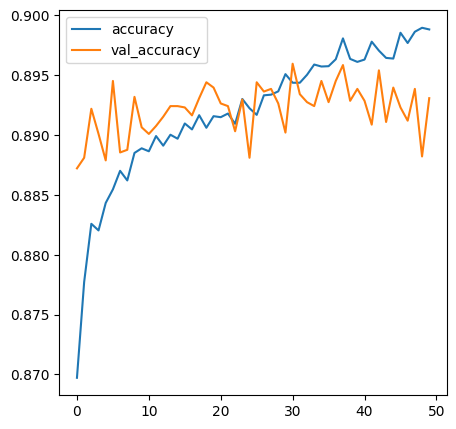

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.plot(history.history['accuracy'],label = 'accuracy')
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.legend()

plt.show()

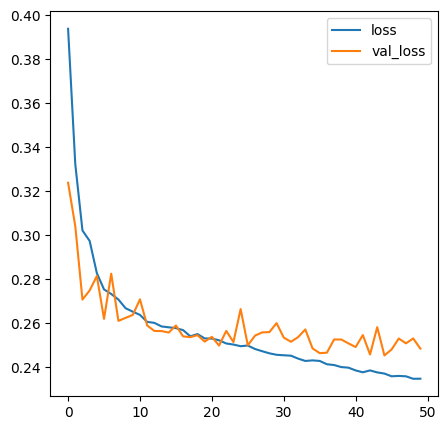

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.plot(history.history['loss'],label = 'loss')
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.legend()

plt.show()